# Criteo 1TB Click Logs — Exploratory Data Analysis

Goal: understand the data well enough to justify the modelling choices (features, encoding, metrics, validation).

**Scope:** only the training days (2015-02-15 and 2015-02-16) are explored here. Validation and test days are kept untouched to avoid leaking information into modelling decisions — the only exception is the drift check in section 7, which compares the two training days with each other.

Data: one parquet part-file per day, downloaded with `scripts/download_data.py`.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
DATA_DIR = Path("../data/raw/data")
TRAIN_DAYS = ["2015-02-15", "2015-02-16"]

LABEL = "label"
INT_COLS = [f"integer_feature_{i}" for i in range(1, 14)]
CAT_COLS = [f"categorical_feature_{i}" for i in range(1, 27)]


def load_days(days: list[str]) -> pd.DataFrame:
    """Load every parquet file of the given days and tag rows with their day."""
    frames = []
    for day in days:
        for path in sorted((DATA_DIR / f"day={day}").glob("*.parquet")):
            frames.append(pd.read_parquet(path).assign(day=day))
    return pd.concat(frames, ignore_index=True)


df = load_days(TRAIN_DAYS)
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

2,308,265 rows x 41 columns


,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,integer_feature_10,integer_feature_11,integer_feature_12,integer_feature_13,categorical_feature_1,categorical_feature_2,categorical_feature_3,categorical_feature_4,categorical_feature_5,categorical_feature_6,categorical_feature_7,categorical_feature_8,categorical_feature_9,categorical_feature_10,categorical_feature_11,categorical_feature_12,categorical_feature_13,categorical_feature_14,categorical_feature_15,categorical_feature_16,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26,day
0,0,NaN,84.0000,NaN,31.0000,12.0000,0.0000,0.0000,1,8,0.0000,3.0000,28899.0000,NaN,8a2b1e43,68fe2a00,f9b6c7f8,9d24e8e8,c6fc10d3,6fcd6dcb,41c974b7,9f591967,2e4e821f,31184e3d,fa478aa9,96aaa628,a77a4a56,NaN,39100785,NaN,NaN,f7389918,139221a3,8024f45f,0683bc6f,fa7eca6c,NaN,e716200f,30436bfc,2ccea557,2015-02-15
1,0,104.0000,1045.0000,30.0000,NaN,1.0000,0.0000,0.0000,1,9,0.0000,1.0000,1527.0000,30.0000,ad98e872,3dbb483e,652f15b0,6521d620,c6fc10d3,6fcd6dcb,674d9101,54cd7262,7cee8453,62da11e3,14874876,4a914b5d,a77a4a56,be4ee537,a63cedcf,4cdc3efa,d20856aa,6785af47,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,c91256e2,30436bfc,e1be5ef2,2015-02-15
2,0,6.0000,145.0000,10.0000,NaN,4.0000,0.0000,0.0000,0,12,0.0000,2.0000,17366.0000,10.0000,788a5d5b,98e2c109,921258ba,f2463ffb,c6fc10d3,6fcd6dcb,e856635a,a66a02fa,2e4e821f,16ec16d6,fa478aa9,8d2db913,a77a4a56,NaN,ded4997d,NaN,NaN,a1eb1511,9512c20b,ef426d46,0683bc6f,6e86ac23,NaN,af97a0c1,30436bfc,b757e957,2015-02-15
3,0,40.0000,360.0000,7.0000,NaN,9.0000,0.0000,0.0000,312,0,0.0000,4.0000,18.0000,7.0000,ad98e872,cea68cd3,d0c5d50f,530c3ed4,c6fc10d3,6fcd6dcb,725b10e7,c0375b13,2e4e821f,62da11e3,14874876,06d701ea,a77a4a56,be4ee537,fdc9e405,4cdc3efa,d20856aa,b8170bba,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,245d9da7,30436bfc,e1be5ef2,2015-02-15
4,0,NaN,339.0000,NaN,NaN,1.0000,0.0000,0.0000,248,7,0.0000,1.0000,28740.0000,NaN,9778ef3a,32934749,3a92e2e0,764c8142,c6fc10d3,6fcd6dcb,9d4501a9,edb0ae6c,2e4e821f,22f47d42,bf694354,12716184,00c5ffb7,NaN,60537734,NaN,NaN,7232d217,9512c20b,14cde947,45f35b4b,f52bfc8b,NaN,edc6442f,ff654802,2ccea557,2015-02-15


In [3]:
df.dtypes.value_counts()

str        27
float64    11
int32       3
Name: count, dtype: int64

In [4]:
def memory_gb(frame: pd.DataFrame) -> float:
    return frame.memory_usage(deep=True).sum() / 1e9


mem_before = memory_gb(df)
df[CAT_COLS] = df[CAT_COLS].astype("category")
mem_after = memory_gb(df)
print(f"Memory with string columns:   {mem_before:.2f} GB")
print(f"Memory with category columns: {mem_after:.2f} GB  ({mem_before / mem_after:.1f}x smaller)")

Memory with string columns:   1.21 GB
Memory with category columns: 0.45 GB  (2.7x smaller)


**Takeaways**
- 2.3M training rows, 13 integer + 26 categorical features.
- Integer columns containing nulls are loaded as `float64` (pandas has no nullable int by default); only `integer_feature_8` and `integer_feature_9` have no missing values and stay `int32`.
- The 26 hashed categorical columns dominate memory. Converting them to `category` makes the frame **2.7x smaller** (1.21 GB → 0.45 GB) → do this systematically in the training pipeline.

## 1. Target

In [5]:
target = df.groupby("day")[LABEL].agg(rows="size", clicks="sum", ctr="mean")
target.loc["total"] = [len(df), df[LABEL].sum(), df[LABEL].mean()]
target.astype({"rows": int, "clicks": int})

,rows,clicks,ctr
day,,,
2015-02-15,1529035,49044,0.0321
2015-02-16,779230,24803,0.0318
total,2308265,73847,0.0320


In [6]:
ctr = df[LABEL].mean()
baseline_logloss = log_loss(df[LABEL], np.full(len(df), ctr))
baseline_accuracy = 1 - ctr

print(f"CTR: {ctr:.4%}  (1 click every {1 / ctr:.0f} impressions)")
print(f"Baseline log loss (always predict the mean CTR): {baseline_logloss:.5f}")
print(f"Accuracy of always predicting 'no click':        {baseline_accuracy:.2%}")

CTR: 3.1992%  (1 click every 31 impressions)


Baseline log loss (always predict the mean CTR): 0.14160
Accuracy of always predicting 'no click':        96.80%


**Takeaways**
- CTR is **3.2%** (1 click every 31 impressions) and almost identical on both days (3.21% vs 3.18%). The data is strongly imbalanced.
- Always predicting "no click" already reaches 96.8% accuracy → **accuracy is meaningless** here.
- Metrics: **log loss** (main metric: the API returns a probability, so its quality matters, not just the ranking) and **ROC-AUC** (ranking quality).
- **Baseline log loss = 0.1416** (constant prediction = train CTR). Every model must beat this.
- No rebalancing (undersampling, class weights): it would distort the predicted probabilities. Note that Criteo subsampled clicks and non-clicks at different rates when publishing the dataset, so probabilities are calibrated to this data, not to real-world traffic.

## 2. Missing values

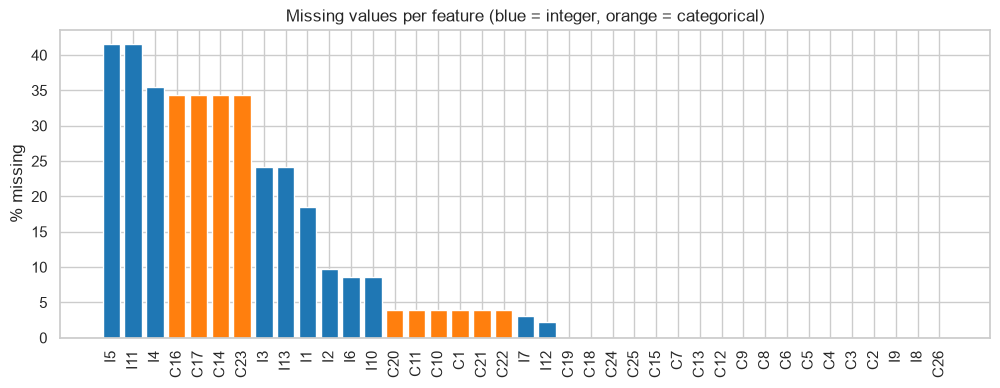

,null_rate
integer_feature_5,0.4150
integer_feature_11,0.4150
integer_feature_4,0.3554
categorical_feature_16,0.3429
categorical_feature_17,0.3429
categorical_feature_14,0.3429
categorical_feature_23,0.3429
integer_feature_3,0.2419
integer_feature_13,0.2419
integer_feature_1,0.1856


In [7]:
FEATURES = INT_COLS + CAT_COLS
null_rate = df[FEATURES].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["tab:blue" if c in INT_COLS else "tab:orange" for c in null_rate.index]
ax.bar(range(len(null_rate)), null_rate.values * 100, color=colors)
ax.set_xticks(range(len(null_rate)))
ax.set_xticklabels([c.replace("integer_feature_", "I").replace("categorical_feature_", "C") for c in null_rate.index], rotation=90)
ax.set_ylabel("% missing")
ax.set_title("Missing values per feature (blue = integer, orange = categorical)")
plt.show()

null_rate[null_rate > 0].to_frame("null_rate")

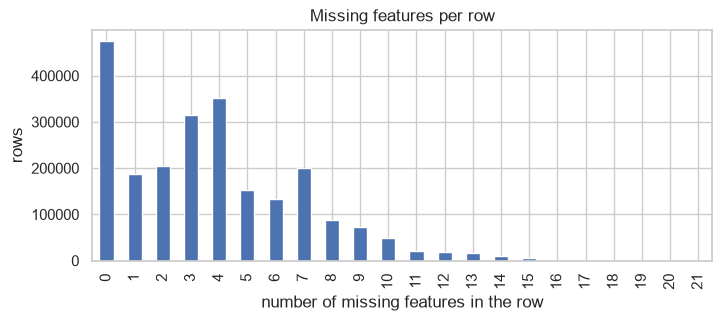

Mean missing features per row: 3.8 / 39
Rows with no missing value:    20.6%


In [8]:
nulls_per_row = df[FEATURES].isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 3))
nulls_per_row.value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("number of missing features in the row")
ax.set_ylabel("rows")
ax.set_title("Missing features per row")
plt.show()

print(f"Mean missing features per row: {nulls_per_row.mean():.1f} / {len(FEATURES)}")
print(f"Rows with no missing value:    {(nulls_per_row == 0).mean():.1%}")

Is missingness informative? Compare the CTR when a feature is missing vs present.

In [9]:
rows = []
for col in null_rate[(null_rate > 0.01) & (null_rate < 0.99)].index:
    is_null = df[col].isna()
    rows.append({
        "feature": col,
        "null_rate": is_null.mean(),
        "ctr_if_missing": df.loc[is_null, LABEL].mean(),
        "ctr_if_present": df.loc[~is_null, LABEL].mean(),
    })
missing_signal = pd.DataFrame(rows).set_index("feature")
missing_signal["ratio"] = missing_signal["ctr_if_missing"] / missing_signal["ctr_if_present"]
missing_signal.sort_values("ratio")

,null_rate,ctr_if_missing,ctr_if_present,ratio
feature,,,,
integer_feature_12,0.0223,0.0148,0.0324,0.4557
integer_feature_4,0.3554,0.0193,0.0390,0.4957
integer_feature_5,0.4150,0.0238,0.0378,0.6298
integer_feature_11,0.4150,0.0238,0.0378,0.6298
categorical_feature_22,0.0394,0.0304,0.0321,0.9479
categorical_feature_21,0.0394,0.0304,0.0321,0.9479
categorical_feature_1,0.0394,0.0304,0.0321,0.9479
categorical_feature_10,0.0394,0.0304,0.0321,0.9479
categorical_feature_11,0.0394,0.0304,0.0321,0.9479


Several features share exactly the same null rate. Check whether they are missing on the *same rows*:

In [10]:
null_masks = df[null_rate[null_rate > 0].index].isna()
groups = {}
for col in null_masks.columns:
    key = hash(null_masks[col].to_numpy().tobytes())
    groups.setdefault(key, []).append(col)

pd.DataFrame(
    [{"null_rate": null_rate[cols[0]], "features": ", ".join(cols)} for cols in groups.values() if len(cols) > 1]
).sort_values("null_rate", ascending=False)

,null_rate,features
0,0.4150,"integer_feature_5, integer_feature_11"
1,0.3429,"categorical_feature_16, categorical_feature_17, categorical_feature_14, categorical_feature_23"
2,0.2419,"integer_feature_3, integer_feature_13"
3,0.0854,"integer_feature_6, integer_feature_10"
4,0.0394,"categorical_feature_20, categorical_feature_11, categorical_feature_10, categorical_feature_1, categorical_feature_2..."


**Takeaways**
- 21 of 39 features have missing values, up to **41.5%** (`integer_feature_5`, `integer_feature_11`). The 18 other features are always filled. On average a row misses 3.8 features; only 20.6% of rows are complete.
- Missing values come in **blocks**: features with the same null rate are missing on exactly the same rows (e.g. categoricals 14/16/17/23, integers 5/11). They probably come from the same upstream source (e.g. a user- or publisher-level signal that is not always available).
- **Missingness is predictive**: CTR is 2x lower when `integer_feature_4` or `integer_feature_12` is missing, and 1.5x higher when `integer_feature_1` is missing. Missing values must be kept as information, not imputed away.
- No feature is so empty that it should be dropped.

→ **Decision**
- LightGBM / trees: pass nulls as-is (native missing handling learns the best direction).
- Logistic regression / neural nets: `log1p` then fill integer nulls with 0 **and** add an `is_missing` flag per integer feature; map missing categoricals to a dedicated `"MISSING"` token.

## 3. Integer features

In [11]:
int_stats = df[INT_COLS].describe(percentiles=[0.01, 0.5, 0.99]).T
int_stats["n_unique"] = df[INT_COLS].nunique()
int_stats["n_negative"] = (df[INT_COLS] < 0).sum()
int_stats

,count,mean,std,min,1%,50%,99%,max,n_unique,n_negative
integer_feature_1,1879954.0000,36.1601,494.3491,1.0000,1.0000,8.0000,306.0000,65535.0000,3708,0
integer_feature_2,2082936.0000,432.6900,710.2696,1.0000,1.0000,196.0000,3408.0000,8000.0000,7672,0
integer_feature_3,1749991.0000,7.2382,10.7809,0.0000,0.0000,4.0000,41.0000,3480.0000,345,0
integer_feature_4,1487816.0000,134.4634,692.4729,0.0000,0.0000,34.0000,1608.0000,244016.0000,6620,0
integer_feature_5,1350418.0000,21.7509,74.5898,1.0000,1.0000,6.0000,279.0000,5115.0000,1773,0
integer_feature_6,2111193.0000,1.5765,6.6604,0.0000,0.0000,0.0000,26.0000,943.0000,308,0
integer_feature_7,2238379.0000,0.1592,2.1330,0.0000,0.0000,0.0000,3.0000,983.0000,176,0
integer_feature_8,2308265.0000,112.7497,386.8680,-1.0000,-1.0000,5.0000,2247.0000,21095.0000,4750,144253
integer_feature_9,2308265.0000,9.8374,18.3551,0.0000,0.0000,5.0000,47.0000,14019.0000,178,0
integer_feature_10,2111193.0000,0.2811,0.5523,0.0000,0.0000,0.0000,2.0000,9.0000,10,0


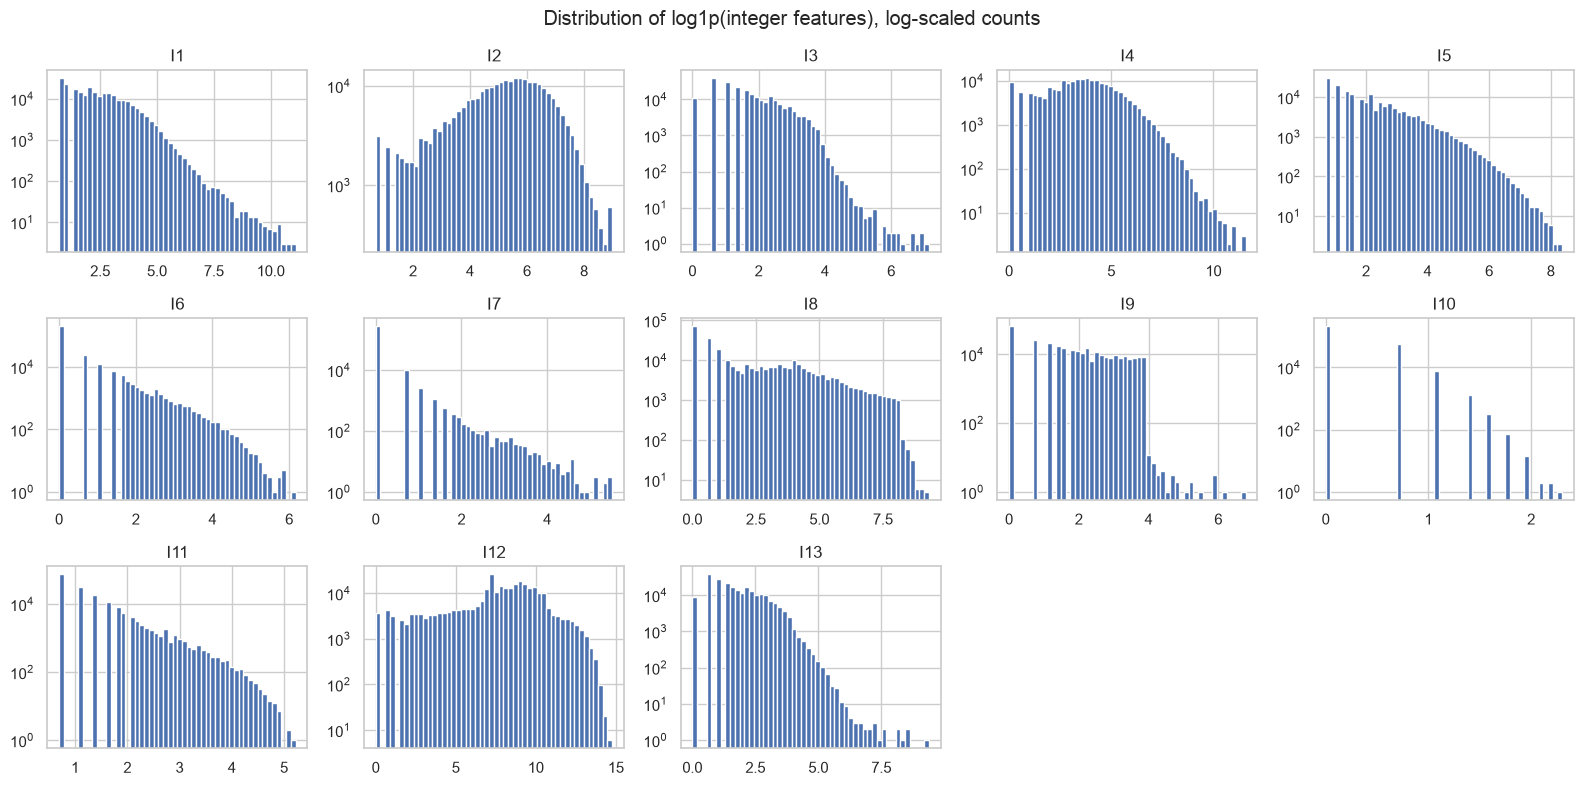

In [12]:
sample = df.sample(300_000, random_state=42)

fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for ax, col in zip(axes.flat, INT_COLS):
    values = sample[col].dropna()
    ax.hist(np.log1p(values.clip(lower=0)), bins=50)
    ax.set_title(col.replace("integer_feature_", "I"))
    ax.set_yscale("log")
for ax in axes.flat[len(INT_COLS):]:
    ax.axis("off")
fig.suptitle("Distribution of log1p(integer features), log-scaled counts")
fig.tight_layout()
plt.show()

Signal check: CTR per decile of each feature (missing values shown as a separate point on the left).

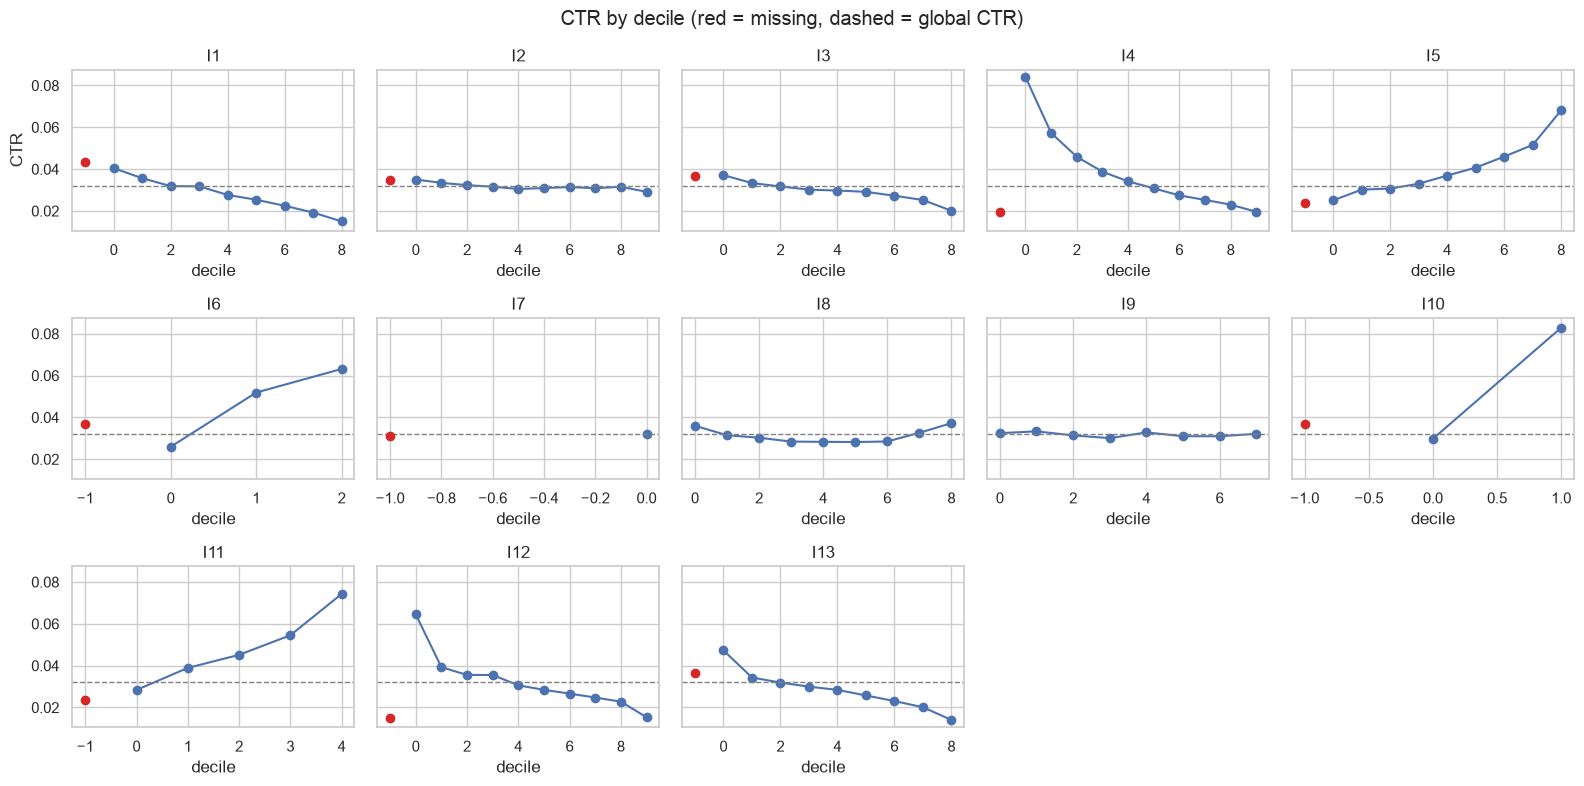

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8), sharey=True)
for ax, col in zip(axes.flat, INT_COLS):
    bins = pd.qcut(df[col], q=10, duplicates="drop")
    ctr_by_bin = df.groupby(bins, observed=True)[LABEL].mean()
    ax.plot(range(len(ctr_by_bin)), ctr_by_bin.values, marker="o")
    if df[col].isna().any():
        ax.scatter([-1], [df.loc[df[col].isna(), LABEL].mean()], color="tab:red", zorder=3)
    ax.axhline(ctr, color="grey", linestyle="--", linewidth=1)
    ax.set_title(col.replace("integer_feature_", "I"))
    ax.set_xlabel("decile")
for ax in axes.flat[len(INT_COLS):]:
    ax.axis("off")
axes[0, 0].set_ylabel("CTR")
fig.suptitle("CTR by decile (red = missing, dashed = global CTR)")
fig.tight_layout()
plt.show()

In [14]:
spread = {}
for col in INT_COLS:
    ctr_by_bin = df.groupby(pd.qcut(df[col], q=10, duplicates="drop"), observed=True)[LABEL].mean()
    spread[col] = ctr_by_bin.max() / ctr_by_bin.min()
pd.Series(spread, name="max/min CTR across deciles").sort_values(ascending=False).to_frame()

,max/min CTR across deciles
integer_feature_4,4.2869
integer_feature_12,4.2059
integer_feature_13,3.3707
integer_feature_10,2.7843
integer_feature_5,2.7162
integer_feature_1,2.6969
integer_feature_11,2.6192
integer_feature_6,2.4332
integer_feature_3,1.8461
integer_feature_8,1.3206


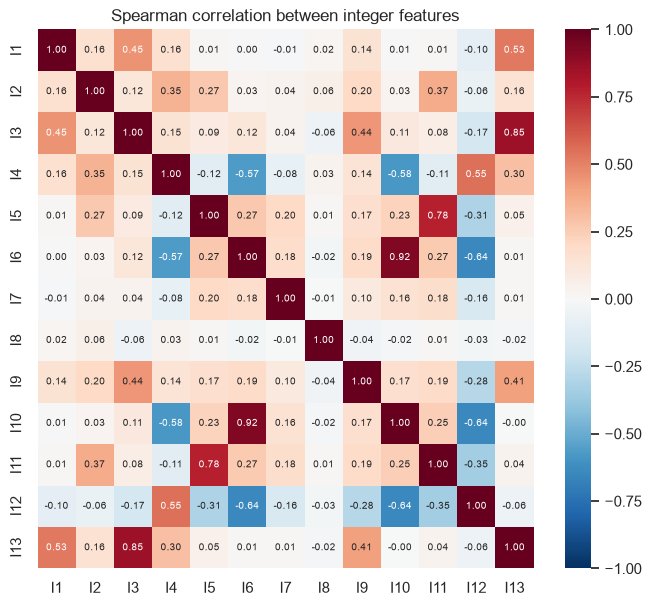

In [15]:
corr = df[INT_COLS].corr(method="spearman")
labels = [c.replace("integer_feature_", "I") for c in INT_COLS]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman correlation between integer features")
plt.show()

`integer_feature_8` is the only feature with negative values, and they are all `-1` — likely a sentinel for "missing" (this column has no nulls). `integer_feature_7` is almost always 0 (its deciles collapse into a single bin).

In [16]:
i8 = df["integer_feature_8"]
print(f"Values < 0 in integer_feature_8: {sorted(i8[i8 < 0].unique())}, {(i8 == -1).mean():.2%} of rows")
print(f"CTR when -1: {df.loc[i8 == -1, LABEL].mean():.4f}   CTR otherwise: {df.loc[i8 >= 0, LABEL].mean():.4f}")

i7 = df["integer_feature_7"]
print(f"\ninteger_feature_7 == 0: {(i7.dropna() == 0).mean():.2%} of non-null rows")
df.groupby(i7.clip(upper=3))[LABEL].agg(rows="size", ctr="mean")

Values < 0 in integer_feature_8: [np.int32(-1)], 6.25% of rows
CTR when -1: 0.0480   CTR otherwise: 0.0309

integer_feature_7 == 0: 94.34% of non-null rows


,rows,ctr
integer_feature_7,,
0.0000,2111578,0.0314
1.0000,79860,0.0364
2.0000,20181,0.0471
3.0000,26760,0.0586


**Takeaways**
- All integer features are **counts with very long tails** (e.g. `integer_feature_12`: median 2,964, max 3M; `integer_feature_4`: 99th percentile 1,608, max 244k). After `log1p` the distributions become well-behaved.
- `integer_feature_8` uses **`-1` as a missing-value sentinel** (6.25% of rows) and that value is informative (CTR 4.8% vs 3.1%).
- `integer_feature_7` is 0 in ~94% of non-null rows but the rare non-zero values carry signal (CTR rises from 3.1% to 5.9%).
- **Strongest univariate signal** (CTR ratio between best and worst decile): `integer_feature_4`, `integer_feature_12` (~4.2x), `integer_feature_13` (3.4x). Weakest: `integer_feature_2`, `integer_feature_9`, `integer_feature_7` (flat across deciles). Relations are mostly **monotonic** but non-linear (e.g. steep drop over the first deciles of `integer_feature_4`).
- Some strongly correlated pairs (Spearman): I6–I10 (0.92), I3–I13 (0.85), I5–I11 (0.78) — these are also the pairs that are missing together, so they likely describe the same entity. Not a problem for trees; mild redundancy for linear models.

→ **Decision**
- Trees: use raw values (invariant to monotonic transforms), treat `-1` in `integer_feature_8` as missing.
- Linear / neural models: replace `-1` by missing, then `log1p` (optionally clip at the 99.9th percentile), then the missing flag + fill from section 2. Standardise for the neural net.

## 4. Categorical features

In [17]:
rows = []
for col in CAT_COLS:
    counts = df[col].value_counts()  # excludes nulls
    rows.append({
        "feature": col,
        "n_unique": len(counts),
        "top_value_share": counts.iloc[0] / counts.sum(),
        "values_seen_once": (counts == 1).mean(),
        "rows_with_value_seen_lt_10": counts[counts < 10].sum() / counts.sum(),
    })
cat_stats = pd.DataFrame(rows).set_index("feature").sort_values("n_unique", ascending=False)
cat_stats

,n_unique,top_value_share,values_seen_once,rows_with_value_seen_lt_10
feature,,,,
categorical_feature_20,543367,0.2437,0.8705,0.2997
categorical_feature_1,499265,0.2437,0.8584,0.2798
categorical_feature_22,455601,0.2437,0.8452,0.2601
categorical_feature_10,374717,0.2437,0.8144,0.2232
categorical_feature_21,211807,0.2437,0.7155,0.1423
categorical_feature_11,77781,0.2444,0.5382,0.0621
categorical_feature_12,66565,0.2101,0.3683,0.0550
categorical_feature_23,60755,0.3563,0.4752,0.0761
categorical_feature_5,18689,0.2066,0.0225,0.0228


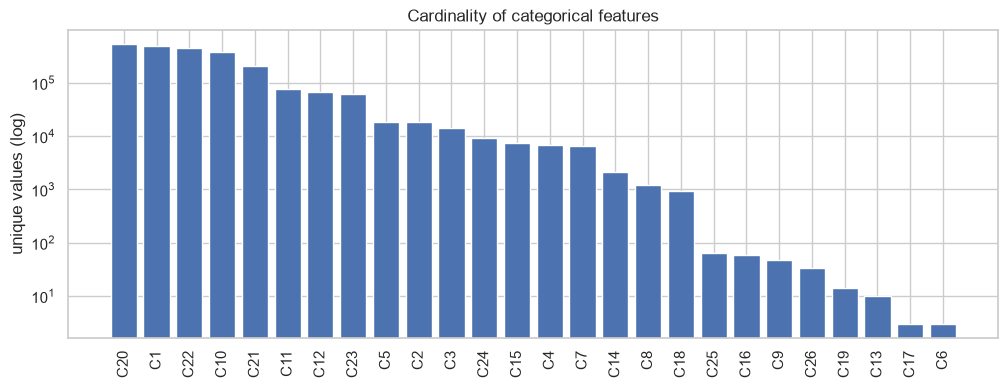

Total unique values across all categorical features: 2,375,475


In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(cat_stats)), cat_stats["n_unique"])
ax.set_xticks(range(len(cat_stats)))
ax.set_xticklabels([c.replace("categorical_feature_", "C") for c in cat_stats.index], rotation=90)
ax.set_yscale("log")
ax.set_ylabel("unique values (log)")
ax.set_title("Cardinality of categorical features")
plt.show()

print(f"Total unique values across all categorical features: {cat_stats['n_unique'].sum():,}")

Long tail: what share of rows is covered by the *k* most frequent values?

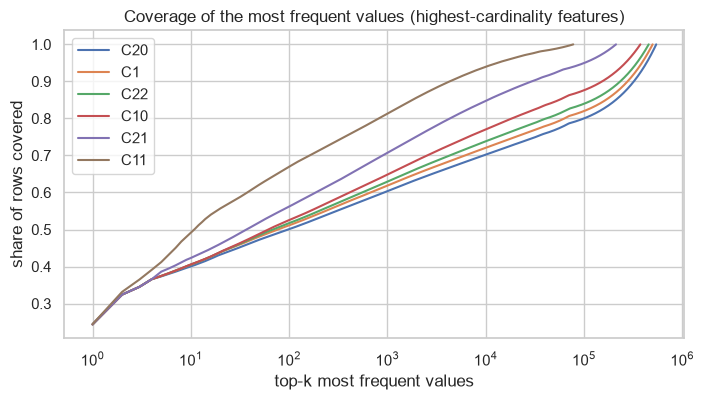

,top_10,top_100,top_1000,top_10000
categorical_feature_20,0.4003,0.5009,0.6037,0.7022
categorical_feature_1,0.4052,0.5113,0.6186,0.7208
categorical_feature_22,0.4052,0.5173,0.6294,0.7382
categorical_feature_10,0.4056,0.5255,0.6483,0.7706
categorical_feature_21,0.4232,0.5621,0.7072,0.8475
categorical_feature_11,0.4911,0.6695,0.8127,0.9395


In [19]:
high_card = cat_stats.index[:6]

fig, ax = plt.subplots(figsize=(8, 4))
for col in high_card:
    counts = df[col].value_counts()
    coverage = counts.cumsum() / counts.sum()
    ax.plot(np.arange(1, len(coverage) + 1), coverage.values, label=col.replace("categorical_feature_", "C"))
ax.set_xscale("log")
ax.set_xlabel("top-k most frequent values")
ax.set_ylabel("share of rows covered")
ax.set_title("Coverage of the most frequent values (highest-cardinality features)")
ax.legend()
plt.show()

coverage_table = {}
for col in high_card:
    counts = df[col].value_counts()
    cum = counts.cumsum() / counts.sum()
    coverage_table[col] = {f"top_{k}": cum.iloc[min(k, len(cum)) - 1] for k in (10, 100, 1_000, 10_000)}
pd.DataFrame(coverage_table).T

Signal check: how much does each categorical feature tell about clicks on its own?
A smoothed target encoding is fitted on day 1 and evaluated on day 2 (so the score is not inflated by memorising rare values). Values unseen on day 1 get the global CTR.

In [20]:
day1 = df["day"] == TRAIN_DAYS[0]
day2 = ~day1
prior = df.loc[day1, LABEL].mean()
SMOOTHING = 20  # pseudo-count pulling rare values towards the global CTR

cat_auc = {}
for col in CAT_COLS:
    stats = df[day1].groupby(col, observed=True)[LABEL].agg(["sum", "count"])
    encoding = (stats["sum"] + SMOOTHING * prior) / (stats["count"] + SMOOTHING)
    encoded = df.loc[day2, col].astype(object).map(encoding).astype(float).fillna(prior)
    cat_auc[col] = roc_auc_score(df.loc[day2, LABEL], encoded)

cat_stats["target_encoding_auc"] = pd.Series(cat_auc)
cat_stats.sort_values("target_encoding_auc", ascending=False)[["n_unique", "target_encoding_auc"]]

,n_unique,target_encoding_auc
feature,,
categorical_feature_2,18351,0.6461
categorical_feature_3,14213,0.6426
categorical_feature_7,6424,0.6370
categorical_feature_24,9197,0.6367
categorical_feature_15,7338,0.6349
categorical_feature_21,211807,0.6100
categorical_feature_10,374717,0.6076
categorical_feature_11,77781,0.6051
categorical_feature_22,455601,0.6041


Choosing a frequency threshold for rare values: vocabulary size kept vs share of rows mapped to `OTHER`.

In [21]:
value_counts = {col: df[col].value_counts() for col in CAT_COLS}
rows = []
for min_count in (1, 5, 10, 20, 50, 100):
    kept = sum((vc >= min_count).sum() for vc in value_counts.values())
    other = np.mean([vc[vc < min_count].sum() / len(df) for vc in value_counts.values()])
    rows.append({"min_count": min_count, "vocabulary_size": kept, "avg_share_of_rows_to_OTHER": other})
pd.DataFrame(rows).set_index("min_count")

,vocabulary_size,avg_share_of_rows_to_OTHER
min_count,,
1,2375475,0.0000
5,231489,0.0433
10,140920,0.0533
20,84654,0.0658
50,46165,0.0855
100,28194,0.1065


**Takeaways**
- Cardinality ranges from **3 to 543k** unique values per feature (**2.4M** in total on 2.3M rows). One-hot encoding is not an option.
- Extremely **long tail**: in the 5 largest features, 72–87% of the values appear only once. Yet the head is heavy: the 10 most frequent values already cover ~40% of rows.
- `categorical_feature_1/10/20/21/22` share the same top value covering 24.4% of rows — probably a default hash (e.g. "unknown user") rather than a real value.
- **Rare-value threshold**: keeping values seen ≥ 10 times shrinks the vocabulary from 2.4M to **141k** (17x smaller) while only 5.3% of rows (on average per feature) fall into `OTHER`. Going from 10 to 5 would add 90k entries for only 1% more rows covered.
- **Signal** (out-of-day target-encoding AUC): the best features are medium-cardinality ones (`categorical_feature_2/3/7/24/15`, AUC ~0.64). High-cardinality features are useful too (~0.60). `categorical_feature_4/5/18` carry no signal on their own (AUC ~0.50), but may still help through interactions.

→ **Decision**
- Map values seen **fewer than 10 times** in the training data to `OTHER` (vocabulary ~141k), plus dedicated tokens for `MISSING` and values unseen at training time.
- LightGBM: native categorical features on the capped vocabulary.
- Logistic regression: hashing trick (2^20 buckets) on the categorical values — no vocabulary to store.
- Neural network: one embedding table per feature on the capped vocabulary.
- Keep all features for now; let the models' feature importances confirm whether `categorical_feature_4/5/18` can be dropped.

## 5. Unseen categorical values

In production the model will constantly receive categorical values it never saw during training. Simulate it: vocabulary built on day 1, applied to day 2.

In [22]:
MIN_COUNT = 10

rows = []
for col in CAT_COLS:
    day1_counts = df.loc[day1, col].value_counts()
    day1_counts = day1_counts[day1_counts > 0]  # category dtype also lists values that only exist on day 2
    day2_values = df.loc[day2, col].dropna().astype(object)
    seen = day2_values.isin(day1_counts.index)
    frequent = day2_values.isin(day1_counts.index[day1_counts >= MIN_COUNT])
    rows.append({
        "feature": col,
        "distinct_values_unseen": 1 - day2_values[seen].nunique() / day2_values.nunique(),
        "rows_unseen": 1 - seen.mean(),
        f"rows_unseen_or_count_lt_{MIN_COUNT}": 1 - frequent.mean(),
    })
unseen = pd.DataFrame(rows).set_index("feature").sort_values("rows_unseen", ascending=False)
unseen

,distinct_values_unseen,rows_unseen,rows_unseen_or_count_lt_10
feature,,,
categorical_feature_20,0.8185,0.2517,0.3320
categorical_feature_1,0.8001,0.2301,0.3130
categorical_feature_22,0.7749,0.2062,0.2926
categorical_feature_10,0.7217,0.1634,0.2564
categorical_feature_21,0.5819,0.0848,0.1735
categorical_feature_23,0.3241,0.0262,0.1016
categorical_feature_11,0.3839,0.0259,0.0833
categorical_feature_12,0.2288,0.0185,0.0815
categorical_feature_3,0.0328,0.0103,0.0238


In [23]:
unseen_rows = pd.DataFrame(
    {col: ~df.loc[day2, col].dropna().astype(object).isin(df.loc[day1, col].dropna().unique()) for col in CAT_COLS}
)
any_unseen = unseen_rows.any(axis=1)
print(f"Day-2 rows with at least one unseen categorical value: {any_unseen.mean():.1%}")

Day-2 rows with at least one unseen categorical value: 26.3%


**Takeaways**
- New values appear constantly: on the high-cardinality features, **72–82% of the distinct day-2 values were never seen on day 1**, which represents **16–25% of day-2 rows**. **26.3%** of day-2 rows contain at least one unseen value.
- With the `min_count = 10` vocabulary, up to 33% of rows fall back to `OTHER`/unknown for the largest features; low-cardinality features are stable (almost no unseen values).
- This is measured on a sample (one file per day): with more training data the vocabulary covers more, but the phenomenon remains — it is inherent to ad data (new ads, new publishers, new users every day).

→ **Decision**
- The preprocessing must map any unknown value to an `UNKNOWN`/`OTHER` index and **never fail** on it. This is a required unit test for the feature pipeline and for the API.
- It also argues for regular retraining in a real system (the vocabulary goes stale within a day).